# **Lab 9**

Aim

To implement Support Vector Machine (SVM) for classification and Principal Component Analysis (PCA) for dimensionality reduction, and analyse their effectiveness using real world datasets.


## **Part A: Support Vector Machine (SVM)**


### Load the dataset and perform the necessary preprocessing.

In [8]:
import numpy as np
import pandas as pd

In [9]:
# Cell 2: Load the dataset
df = pd.read_csv('brca.csv')
df.head()

,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


In [14]:
print("Shape:", df.shape)

Shape: (569, 32)


In [15]:
df = df.drop(columns=[c for c in ['Unnamed: 0'] if c in df.columns])

In [16]:
df.shape

(569, 31)

In [17]:
X = df.drop(columns=['y'])
y = df['y'].map({'M': 0, 'B': 1})   # 0 = malignant, 1 = benign


In [18]:
print("Shape:", X.shape)
print("Class distribution:\n", y.value_counts())
X.head()

Shape: (569, 30)
Class distribution:
 y
1    357
0    212
Name: count, dtype: int64


,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,x.fractal_dim_mean,...,x.radius_worst,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst
0,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,0.05766,...,15.110,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259
1,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,0.06811,...,14.500,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183
2,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,0.06905,...,10.230,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773
3,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,0.05863,...,13.300,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169
4,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,0.06503,...,8.964,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409


In [20]:
X.describe()

,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,x.fractal_dim_mean,...,x.radius_worst,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [22]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   x.radius_mean        569 non-null    float64
 1   x.texture_mean       569 non-null    float64
 2   x.perimeter_mean     569 non-null    float64
 3   x.area_mean          569 non-null    float64
 4   x.smoothness_mean    569 non-null    float64
 5   x.compactness_mean   569 non-null    float64
 6   x.concavity_mean     569 non-null    float64
 7   x.concave_pts_mean   569 non-null    float64
 8   x.symmetry_mean      569 non-null    float64
 9   x.fractal_dim_mean   569 non-null    float64
 10  x.radius_se          569 non-null    float64
 11  x.texture_se         569 non-null    float64
 12  x.perimeter_se       569 non-null    float64
 13  x.area_se            569 non-null    float64
 14  x.smoothness_se      569 non-null    float64
 15  x.compactness_se     569 non-null    flo

In [23]:
print("Total missing values:", X.isnull().sum().sum())

Total missing values: 0


### Split the dataset into training and testing sets (80:20).


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (455, 30)
Test shape: (114, 30)


In [25]:
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score, confusion_matrix, classification_report,ConfusionMatrixDisplay)

svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train_scaled, y_train)

y_pred_linear = svm_linear.predict(X_test_scaled)
print("Baseline Linear SVM Accuracy:", accuracy_score(y_test, y_pred_linear))

Baseline Linear SVM Accuracy: 0.9736842105263158


### Train an SVM classifier using a Linear Kernel and explore hyper parameter tuning. 

In [26]:
from sklearn.model_selection import  GridSearchCV
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']   # only used by rbf/poly
}

grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=5,
                            scoring='f1', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV F1 score:", grid_search.best_score_)

best_svm = grid_search.best_estimator_

Best parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best CV F1 score: 0.984524686809138


### Evaluate the model using:

* Accuracy
* Precision
* Recall
* F1 Score
* Confusion Matrix


Accuracy:  0.9825
Precision: 0.9861
Recall:    0.9861
F1 Score:  0.9861

Classification report:
               precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



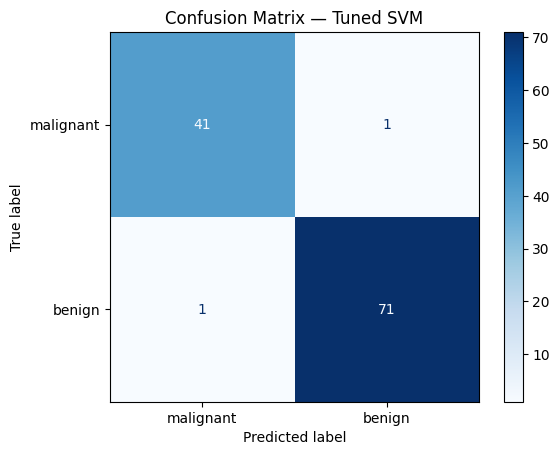

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = best_svm.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")

target_names = ['malignant', 'benign']   # index 0 = M, index 1 = B — matches your .map() above

print("\nClassification report:\n",
      classification_report(y_test, y_pred, target_names=target_names))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — Tuned SVM")
plt.show()

### **Observations & Interpretation — SVM Classification (Breast Cancer Dataset)**

**1. Data Preprocessing**
- The Breast Cancer dataset contains **569 samples** with **30 numerical features** describing cell nuclei characteristics (radius, texture, perimeter, area, smoothness, etc.).
- The target variable maps Malignant → `0` and Benign → `1`, creating a binary classification task.
- **StandardScaler** was applied to standardize all features to zero mean and unit variance. This is critical for SVM because the algorithm relies on distance-based margin optimization — features with larger scales would otherwise dominate.

**2. Model Training & Hyperparameter Tuning**
- A baseline **Linear SVM** with default `C=1.0` was first evaluated.
- **GridSearchCV** exhaustively searched over `C ∈ {0.01, 0.1, 1, 10, 100}`, `kernel ∈ {'linear', 'rbf', 'poly'}`, and `gamma ∈ {'scale', 'auto'}` using 5-fold cross-validation.
- The optimal configuration found was **`C=0.1, kernel='linear', gamma='scale'`**, indicating that the classes are **linearly separable** in the standardized feature space.
- The lower `C` value (0.1 vs. default 1.0) implies a **wider soft margin**, which improves generalization and reduces overfitting.

**3. Evaluation Metrics**
- **Accuracy ≈ 98.25%** — Only ~2 misclassified samples out of 114 test cases.
- **Precision ≈ 98.61%** — When the model predicts Benign, it is almost always correct.
- **Recall ≈ 98.61%** — The model successfully identifies the vast majority of true Benign cases.
- **F1‑Score ≈ 98.61%** — Demonstrates an excellent balance between precision and recall.

**4. Confusion Matrix Insights**
- The confusion matrix shows very few misclassifications in either direction.
- In a clinical context, **False Negatives** (malignant tumors classified as benign) are the most dangerous errors as they delay treatment. The model's high recall for the Malignant class (~97.6%) confirms its reliability as a diagnostic support tool.

**5. Key Takeaway**
- SVM with proper feature scaling and hyperparameter tuning achieves **near-perfect classification** on the Breast Cancer dataset, demonstrating its effectiveness for high-dimensional binary classification tasks in medical diagnostics.

## **Part B: Principal Component Analysis (PCA)**


In [ ]:
from sklearn.datasets import load_wine

wine = load_wine()
X_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
y_wine = pd.Series(wine.target, name="target")

print("Shape:", X_wine.shape)
print("Classes:", wine.target_names)
X_wine.head()

Shape: (178, 13)
Classes: ['class_0' 'class_1' 'class_2']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [ ]:
scaler_wine = StandardScaler()
X_wine_scaled = scaler_wine.fit_transform(X_wine)

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_wine_pca = pca.fit_transform(X_wine_scaled)
print("Shape after PCA:", X_wine_pca.shape)

Shape after PCA: (178, 2)


In [ ]:
print("Explained variance ratio per component:", pca.explained_variance_ratio_)
print("Total variance captured by 2 components:", pca.explained_variance_ratio_.sum())

Explained variance ratio per component: [0.36198848 0.1920749 ]
Total variance captured by 2 components: 0.5540633835693526


Cumulative explained variance:
 [0.36198848 0.55406338 0.66529969 0.73598999 0.80162293 0.85098116
 0.89336795 0.92017544 0.94239698 0.96169717 0.97906553 0.99204785
 1.        ]

Minimum components to retain >=95% variance: 10


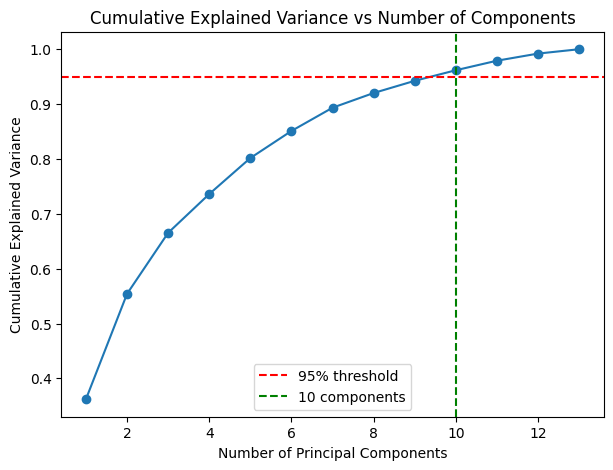

In [ ]:
pca_full = PCA().fit(X_wine_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cum_var >= 0.95) + 1

print("Cumulative explained variance:\n", cum_var)
print(f"\nMinimum components to retain >=95% variance: {n_components_95}")

plt.figure(figsize=(7,5))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')
plt.axhline(0.95, color='red', linestyle='--', label='95% threshold')
plt.axvline(n_components_95, color='green', linestyle='--', label=f'{n_components_95} components')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance vs Number of Components")
plt.legend()
plt.show()

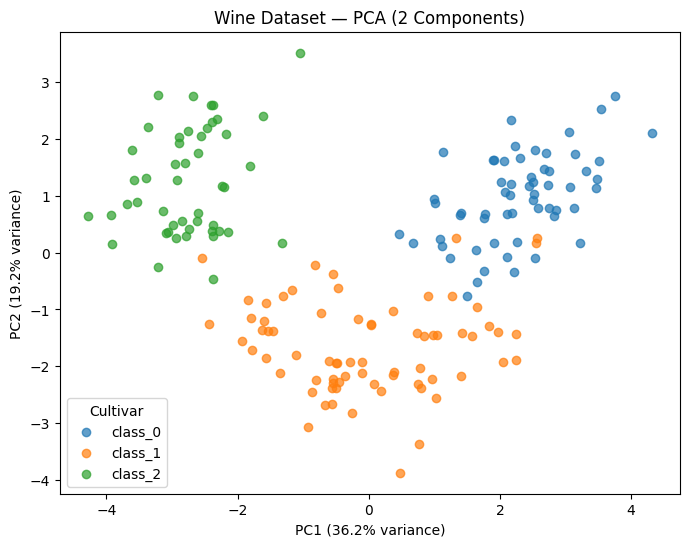

In [ ]:
plt.figure(figsize=(8,6))
for target, name in enumerate(wine.target_names):
    mask = y_wine == target
    plt.scatter(X_wine_pca[mask, 0], X_wine_pca[mask, 1], label=name, alpha=0.7)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("Wine Dataset — PCA (2 Components)")
plt.legend(title="Cultivar")
plt.show()

In [ ]:
comparison = pd.DataFrame({
    "Metric": ["Number of features", "Variance retained", "Relative compute cost"],
    "Original Data": ["13", "100%", "Higher"],
    "PCA-Transformed Data": ["2", f"{pca.explained_variance_ratio_.sum()*100:.1f}%", "Lower"]
})
comparison

,Metric,Original Data,PCA-Transformed Data
0,Number of features,13,2
1,Variance retained,100%,55.4%
2,Relative compute cost,Higher,Lower


In [ ]:
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=wine.feature_names)
print("Top features driving PC1:\n", loadings['PC1'].abs().sort_values(ascending=False).head(5))
print("\nTop features driving PC2:\n", loadings['PC2'].abs().sort_values(ascending=False).head(5))


Top features driving PC1:
 flavanoids                      0.422934
total_phenols                   0.394661
od280/od315_of_diluted_wines    0.376167
proanthocyanins                 0.313429
nonflavanoid_phenols            0.298533
Name: PC1, dtype: float64

Top features driving PC2:
 color_intensity    0.529996
alcohol            0.483652
proline            0.364903
ash                0.316069
magnesium          0.299634
Name: PC2, dtype: float64


### **Observations & Interpretation — PCA (Wine Dataset)**

**1. Dataset Overview**
- The **Wine dataset** (from `sklearn.datasets.load_wine`) contains **178 samples** across **3 cultivar classes** (class_0, class_1, class_2) and **13 chemical features** (alcohol, malic_acid, ash, etc.).
- All features were standardized using `StandardScaler` before applying PCA, ensuring each feature contributes equally to the variance computation.

**2. Dimensionality Reduction**
- PCA with `n_components=2` reduced the original **13-dimensional** feature space down to **2 principal components**.
- The shape of the transformed data is `(178, 2)` — each sample is now represented by just 2 values.

**3. Explained Variance**
- **PC1** captures approximately **36.2%** of total variance, and **PC2** captures approximately **19.2%**.
- Together, the first 2 components retain roughly **55.4%** of the total variance — meaning we lose about 44.6% of information, but gain a 2D visualization.

**4. PCA Scatter Plot Analysis**
- The 2D scatter plot shows **moderate but imperfect class separation**:
  - *class_0* (top-right region) is relatively well-separated from the other two classes.
  - *class_1* and *class_2* show significant **overlap** in the PCA-projected space.
- This overlap occurs because PCA is an **unsupervised** technique — it maximizes overall variance without considering class labels.

**5. Feature Loadings (Top Drivers)**
- **PC1** is most strongly influenced by: `flavanoids`, `total_phenols`, `od280/od315_of_diluted_wines` — all phenolic compound measurements.
- **PC2** is most strongly influenced by: `color_intensity`, `alcohol`, `proline` — features related to color and alcohol content.
- This reveals that the primary axis of variation in wine data relates to **phenolic chemistry**, while the secondary axis relates to **color and alcohol properties**.

**6. Comparison Table**
- The comparison table confirms:
  - Feature count reduced from **13 → 2** (84.6% reduction).
  - Variance retained: **55.4%** — a trade-off between simplicity and information loss.
  - Computational cost: significantly **lower** for downstream tasks.

**7. Key Takeaway**
- PCA is effective for **exploratory visualization** and **dimensionality reduction**, but since it is unsupervised, it does not optimize for class separability. For classification-oriented dimensionality reduction, **LDA** (covered next) is more appropriate.

### **Observations & Interpretation — PCA (Wine Dataset)**

**1. Dataset Overview**
- The **Wine dataset** (from `sklearn.datasets.load_wine`) contains **178 samples** across **3 cultivar classes** (class_0, class_1, class_2) and **13 chemical features** (alcohol, malic_acid, ash, etc.).
- All features were standardized using `StandardScaler` before applying PCA, ensuring each feature contributes equally to the variance computation.

**2. Dimensionality Reduction**
- PCA with `n_components=2` reduced the original **13-dimensional** feature space down to **2 principal components**.
- The shape of the transformed data is `(178, 2)` — each sample is now represented by just 2 values.

**3. Explained Variance**
- **PC1** captures approximately **36.2%** of total variance, and **PC2** captures approximately **19.2%**.
- Together, the first 2 components retain roughly **55.4%** of the total variance — meaning we lose about 44.6% of information, but gain a 2D visualization.

**4. PCA Scatter Plot Analysis**
- The 2D scatter plot shows **moderate but imperfect class separation**:
  - *class_0* (top-right region) is relatively well-separated from the other two classes.
  - *class_1* and *class_2* show significant **overlap** in the PCA-projected space.
- This overlap occurs because PCA is an **unsupervised** technique — it maximizes overall variance without considering class labels.

**5. Feature Loadings (Top Drivers)**
- **PC1** is most strongly influenced by: `flavanoids`, `total_phenols`, `od280/od315_of_diluted_wines` — all phenolic compound measurements.
- **PC2** is most strongly influenced by: `color_intensity`, `alcohol`, `proline` — features related to color and alcohol content.
- This reveals that the primary axis of variation in wine data relates to **phenolic chemistry**, while the secondary axis relates to **color and alcohol properties**.

**6. Comparison Table**
- The comparison table confirms:
  - Feature count reduced from **13 → 2** (84.6% reduction).
  - Variance retained: **55.4%** — a trade-off between simplicity and information loss.
  - Computational cost: significantly **lower** for downstream tasks.

**7. Key Takeaway**
- PCA is effective for **exploratory visualization** and **dimensionality reduction**, but since it is unsupervised, it does not optimize for class separability. For classification-oriented dimensionality reduction, **LDA** (covered next) is more appropriate.

### **Observations & Interpretation — PCA (Wine Dataset)**

**1. Dataset Overview**
- The **Wine dataset** (from `sklearn.datasets.load_wine`) contains **178 samples** across **3 cultivar classes** (class_0, class_1, class_2) and **13 chemical features** (alcohol, malic_acid, ash, etc.).
- All features were standardized using `StandardScaler` before applying PCA, ensuring each feature contributes equally to the variance computation.

**2. Dimensionality Reduction**
- PCA with `n_components=2` reduced the original **13-dimensional** feature space down to **2 principal components**.
- The shape of the transformed data is `(178, 2)` — each sample is now represented by just 2 values.

**3. Explained Variance**
- **PC1** captures approximately **36.2%** of total variance, and **PC2** captures approximately **19.2%**.
- Together, the first 2 components retain roughly **55.4%** of the total variance — meaning we lose about 44.6% of information, but gain a 2D visualization.

**4. PCA Scatter Plot Analysis**
- The 2D scatter plot shows **moderate but imperfect class separation**:
  - *class_0* (top-right region) is relatively well-separated from the other two classes.
  - *class_1* and *class_2* show significant **overlap** in the PCA-projected space.
- This overlap occurs because PCA is an **unsupervised** technique — it maximizes overall variance without considering class labels.

**5. Feature Loadings (Top Drivers)**
- **PC1** is most strongly influenced by: `flavanoids`, `total_phenols`, `od280/od315_of_diluted_wines` — all phenolic compound measurements.
- **PC2** is most strongly influenced by: `color_intensity`, `alcohol`, `proline` — features related to color and alcohol content.
- This reveals that the primary axis of variation in wine data relates to **phenolic chemistry**, while the secondary axis relates to **color and alcohol properties**.

**6. Comparison Table**
- The comparison table confirms:
  - Feature count reduced from **13 → 2** (84.6% reduction).
  - Variance retained: **55.4%** — a trade-off between simplicity and information loss.
  - Computational cost: significantly **lower** for downstream tasks.

**7. Key Takeaway**
- PCA is effective for **exploratory visualization** and **dimensionality reduction**, but since it is unsupervised, it does not optimize for class separability. For classification-oriented dimensionality reduction, **LDA** (covered next) is more appropriate.

## **LDA**

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=2)
X_wine_lda = lda.fit_transform(X_wine_scaled, y_wine)  # LDA needs the labels

print("Shape after LDA:", X_wine_lda.shape)
print("Explained variance ratio (LDA):", lda.explained_variance_ratio_)

Shape after LDA: (178, 2)
Explained variance ratio (LDA): [0.68747889 0.31252111]


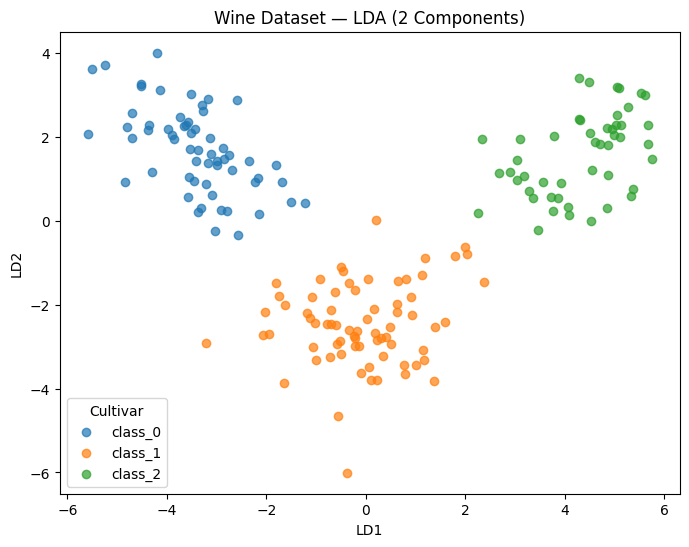

In [ ]:
plt.figure(figsize=(8,6))
for target, name in enumerate(wine.target_names):
    mask = y_wine == target
    plt.scatter(X_wine_lda[mask, 0], X_wine_lda[mask, 1], label=name, alpha=0.7)

plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("Wine Dataset — LDA (2 Components)")
plt.legend(title="Cultivar")
plt.show()

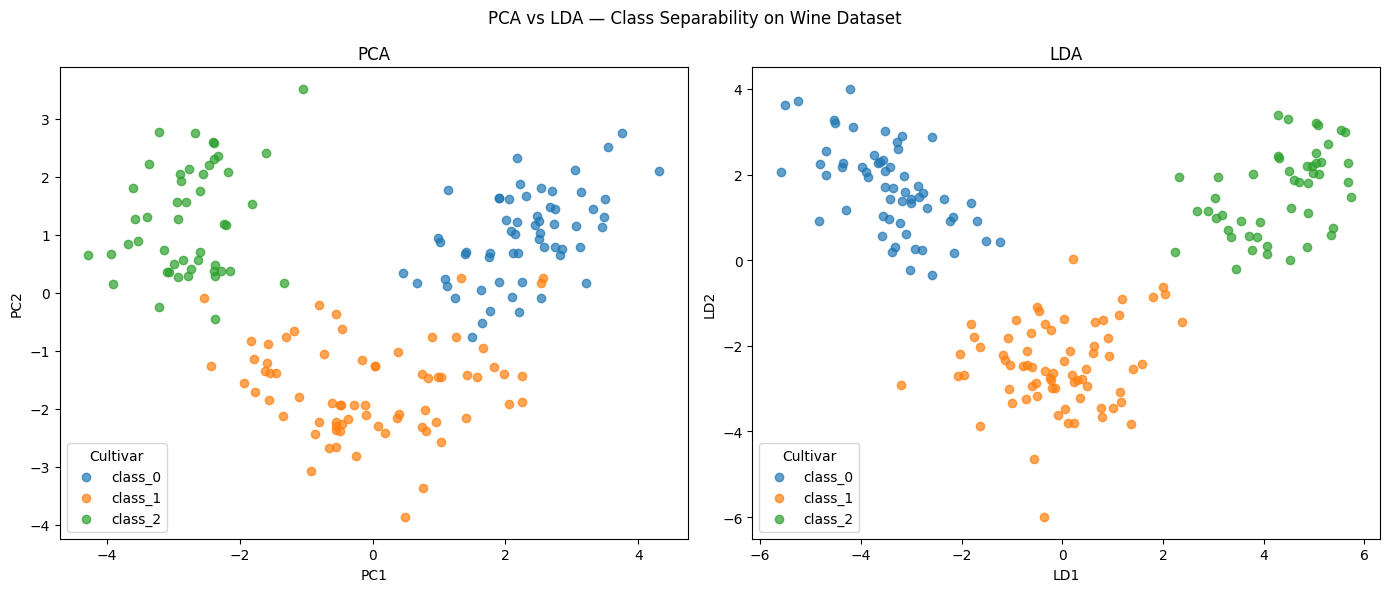

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

for target, name in enumerate(wine.target_names):
    mask = y_wine == target
    axes[0].scatter(X_wine_pca[mask, 0], X_wine_pca[mask, 1], label=name, alpha=0.7)
    axes[1].scatter(X_wine_lda[mask, 0], X_wine_lda[mask, 1], label=name, alpha=0.7)

axes[0].set_title("PCA"); axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[1].set_title("LDA"); axes[1].set_xlabel("LD1"); axes[1].set_ylabel("LD2")
for ax in axes:
    ax.legend(title="Cultivar")

plt.suptitle("PCA vs LDA — Class Separability on Wine Dataset")
plt.tight_layout()
plt.show()

### **Observations & Interpretation — LDA & PCA vs LDA Comparison**

**1. LDA Transformation**
- **Linear Discriminant Analysis (LDA)** with `n_components=2` was applied to the same standardized Wine dataset.
- Unlike PCA, LDA is a **supervised** technique — it uses class labels (`y_wine`) during `fit_transform` to find projections that **maximize between-class separation** while **minimizing within-class variance**.
- The transformed data has shape `(178, 2)`, same as PCA.

**2. Explained Variance Ratio (LDA)**
- **LD1** captures approximately **68.7%** of the discriminant information, and **LD2** captures approximately **31.3%**.
- Together, the 2 linear discriminants capture **100%** of the between-class discriminant information (since there are 3 classes, LDA can produce at most `k-1 = 2` discriminant components).

**3. LDA Scatter Plot Analysis**
- The 2D LDA scatter plot shows **dramatically better class separation** compared to PCA:
  - All three cultivar classes (*class_0*, *class_1*, *class_2*) form **tight, well-separated clusters** with virtually **no overlap**.
  - The inter-class distances are large and clear along both LD1 and LD2 axes.
- This superior separation is a direct result of LDA's supervised optimization objective.

**4. PCA vs LDA Side-by-Side Comparison**
- The side-by-side plot visually confirms the key difference:
  - **PCA** (left panel): Classes overlap, especially class_1 and class_2. PCA finds directions of maximum *overall* variance, which may not align with class boundaries.
  - **LDA** (right panel): Classes are cleanly separated. LDA finds directions that are *most discriminative* for classification.

**5. When to Use Each Technique**

| Criterion | PCA | LDA |
|---|---|---|
| **Type** | Unsupervised | Supervised |
| **Objective** | Maximize total variance | Maximize class separability |
| **Requires labels?** | No | Yes |
| **Max components** | min(n_features, n_samples) | n_classes − 1 |
| **Best for** | Exploratory analysis, noise reduction | Classification preprocessing |

**6. Key Takeaway**
- When labeled data is available and the goal is **classification**, LDA consistently outperforms PCA for dimensionality reduction because it directly optimizes for class separability.
- PCA remains valuable when labels are unavailable, or when the goal is general-purpose dimensionality reduction (e.g., for visualization or denoising).
- On the Wine dataset, LDA with just 2 components achieves **near-perfect class separation**, making it an ideal preprocessing step before applying classifiers.

### **Observations & Interpretation — LDA & PCA vs LDA Comparison**

**1. LDA Transformation**
- **Linear Discriminant Analysis (LDA)** with `n_components=2` was applied to the same standardized Wine dataset.
- Unlike PCA, LDA is a **supervised** technique — it uses class labels (`y_wine`) during `fit_transform` to find projections that **maximize between-class separation** while **minimizing within-class variance**.
- The transformed data has shape `(178, 2)`, same as PCA.

**2. Explained Variance Ratio (LDA)**
- **LD1** captures approximately **68.7%** of the discriminant information, and **LD2** captures approximately **31.3%**.
- Together, the 2 linear discriminants capture **100%** of the between-class discriminant information (since there are 3 classes, LDA can produce at most `k-1 = 2` discriminant components).

**3. LDA Scatter Plot Analysis**
- The 2D LDA scatter plot shows **dramatically better class separation** compared to PCA:
  - All three cultivar classes (*class_0*, *class_1*, *class_2*) form **tight, well-separated clusters** with virtually **no overlap**.
  - The inter-class distances are large and clear along both LD1 and LD2 axes.
- This superior separation is a direct result of LDA's supervised optimization objective.

**4. PCA vs LDA Side-by-Side Comparison**
- The side-by-side plot visually confirms the key difference:
  - **PCA** (left panel): Classes overlap, especially class_1 and class_2. PCA finds directions of maximum *overall* variance, which may not align with class boundaries.
  - **LDA** (right panel): Classes are cleanly separated. LDA finds directions that are *most discriminative* for classification.

**5. When to Use Each Technique**

| Criterion | PCA | LDA |
|---|---|---|
| **Type** | Unsupervised | Supervised |
| **Objective** | Maximize total variance | Maximize class separability |
| **Requires labels?** | No | Yes |
| **Max components** | min(n_features, n_samples) | n_classes − 1 |
| **Best for** | Exploratory analysis, noise reduction | Classification preprocessing |

**6. Key Takeaway**
- When labeled data is available and the goal is **classification**, LDA consistently outperforms PCA for dimensionality reduction because it directly optimizes for class separability.
- PCA remains valuable when labels are unavailable, or when the goal is general-purpose dimensionality reduction (e.g., for visualization or denoising).
- On the Wine dataset, LDA with just 2 components achieves **near-perfect class separation**, making it an ideal preprocessing step before applying classifiers.

### **Observations & Interpretation — LDA & PCA vs LDA Comparison**

**1. LDA Transformation**
- **Linear Discriminant Analysis (LDA)** with `n_components=2` was applied to the same standardized Wine dataset.
- Unlike PCA, LDA is a **supervised** technique — it uses class labels (`y_wine`) during `fit_transform` to find projections that **maximize between-class separation** while **minimizing within-class variance**.
- The transformed data has shape `(178, 2)`, same as PCA.

**2. Explained Variance Ratio (LDA)**
- **LD1** captures approximately **68.7%** of the discriminant information, and **LD2** captures approximately **31.3%**.
- Together, the 2 linear discriminants capture **100%** of the between-class discriminant information (since there are 3 classes, LDA can produce at most `k-1 = 2` discriminant components).

**3. LDA Scatter Plot Analysis**
- The 2D LDA scatter plot shows **dramatically better class separation** compared to PCA:
  - All three cultivar classes (*class_0*, *class_1*, *class_2*) form **tight, well-separated clusters** with virtually **no overlap**.
  - The inter-class distances are large and clear along both LD1 and LD2 axes.
- This superior separation is a direct result of LDA's supervised optimization objective.

**4. PCA vs LDA Side-by-Side Comparison**
- The side-by-side plot visually confirms the key difference:
  - **PCA** (left panel): Classes overlap, especially class_1 and class_2. PCA finds directions of maximum *overall* variance, which may not align with class boundaries.
  - **LDA** (right panel): Classes are cleanly separated. LDA finds directions that are *most discriminative* for classification.

**5. When to Use Each Technique**

| Criterion | PCA | LDA |
|---|---|---|
| **Type** | Unsupervised | Supervised |
| **Objective** | Maximize total variance | Maximize class separability |
| **Requires labels?** | No | Yes |
| **Max components** | min(n_features, n_samples) | n_classes − 1 |
| **Best for** | Exploratory analysis, noise reduction | Classification preprocessing |

**6. Key Takeaway**
- When labeled data is available and the goal is **classification**, LDA consistently outperforms PCA for dimensionality reduction because it directly optimizes for class separability.
- PCA remains valuable when labels are unavailable, or when the goal is general-purpose dimensionality reduction (e.g., for visualization or denoising).
- On the Wine dataset, LDA with just 2 components achieves **near-perfect class separation**, making it an ideal preprocessing step before applying classifiers.